# Section 7 — Pipeline Attention : de la Clé au Logit

Ce notebook explique **comment le modèle choisit le prochain nœud**, étape par étape,
avec des calculs numériques réels sur notre instance VRPTW.

## Les 9 étapes du pipeline

```
1. La brique de base : nn.Linear  (W · x + b)
2. L'espace vectoriel             (features → 128 chiffres)
3. L'encodeur                     (chaque ville connaît ses voisines)
4. La requête                     (ce que le véhicule cherche)
5. Les clés                       (ce que chaque ville propose)
6. La comparaison                 (score = q · k)
7. Normalisation / √d             (éviter l'explosion des scores)
8. Le masque                      (bloquer les nœuds interdits)
9. Softmax → décision             (scores → probabilités → choix)
```

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys, os

# Chemins
PHASE4 = os.path.abspath('.')
sys.path.insert(0, PHASE4)

from preprocess import generate_instance
from oracle import resoudre_instance
from build_decision_dataset import (
    compute_static_node_features,
    extract_decision_examples_from_solution,
)
from model import VRPTWAttentionModel
from inference_decoder import load_trained_model

# Instance de démonstration
SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)
sol      = resoudre_instance(instance, time_limit_s=5.0)
examples = extract_decision_examples_from_solution(instance, sol)

# Modèle entraîné
model = load_trained_model('artifacts_train_small/best_model.pt')
model.eval()

print(f'Instance : {N} clients, {instance["n_vehicles"]} véhicules')
print(f'Modèle   : {sum(p.numel() for p in model.parameters()):,} paramètres')
print(f'Exemples : {len(examples)} décisions à expliquer')

Instance : 10 clients, 3 véhicules
Modèle   : 695,936 paramètres
Exemples : 13 décisions à expliquer


---
## Étape 1 — La brique de base : `nn.Linear` (W · x + b)

**Tout le modèle repose sur une seule opération** :

```
sortie = W · entrée + b
```

- `W` : matrice de **poids** — transforme l'entrée. Apprise par gradient descent.
- `b` : vecteur de **biais** — décalage de base. Appris par gradient descent.

Au départ, `W` et `b` sont **aléatoires**. L'entraînement les ajuste progressivement pour que les routes produites soient les plus courtes possibles.

### Exemple minimal : 3 features → 2 dimensions

In [2]:
# Exemple numérique de nn.Linear
torch.manual_seed(0)

# Imaginez un client avec 3 features : coord_x=10, coord_y=5, demande=0.3
x = torch.tensor([10.0, 5.0, 0.3])

# Une couche linéaire 3 → 2
layer = nn.Linear(3, 2)

# Afficher W et b
print("W (poids) — shape", list(layer.weight.shape), ":")
print(layer.weight.data.numpy().round(4))
print()
print("b (biais) — shape", list(layer.bias.shape), ":")
print(layer.bias.data.numpy().round(4))
print()

# Calcul manuel
W = layer.weight.data.numpy()
b = layer.bias.data.numpy()
x_np = x.numpy()

sortie_manuelle = W @ x_np + b

with torch.no_grad():
    sortie_pytorch = layer(x).numpy()

print("Calcul manuel   W·x + b :", sortie_manuelle.round(4))
print("PyTorch layer(x)        :", sortie_pytorch.round(4))
print("Identiques ?            :", np.allclose(sortie_manuelle, sortie_pytorch))
print()
print("→ nn.Linear = juste une multiplication matricielle + ajout du biais.")
print("  W et b sont les SEULS chiffres que le réseau apprend dans cette couche.")

W (poids) — shape [2, 3] :
[[-0.0043  0.3097 -0.4752]
 [-0.4249 -0.2224  0.1548]]

b (biais) — shape [2] :
[-0.0114  0.4578]

Calcul manuel   W·x + b : [ 1.3514 -4.8566]
PyTorch layer(x)        : [ 1.3514 -4.8566]
Identiques ?            : True

→ nn.Linear = juste une multiplication matricielle + ajout du biais.
  W et b sont les SEULS chiffres que le réseau apprend dans cette couche.


### Rôle de W vs rôle de b

| | `W` | `b` |
|--|--|--|
| **Rôle** | Transformer les données (rotation, étirement, projection) | Décaler la sortie (point de départ) |
| **Sans lui** | sortie nulle si entrée nulle | le modèle doit tout encoder dans W |
| **Analogie** | La pente d'une droite | L'ordonnée à l'origine |
| **Appris par** | Gradient descent | Gradient descent |

**Note** : `W_q` et `W_k` dans notre modèle n'ont **pas** de biais (`bias=False`) car un biais constant
ne change pas le résultat du softmax — il décalerait tous les scores de la même valeur, ce qui s'annule.

---
## Étape 2 — L'espace vectoriel : features → 128 chiffres

Les features brutes (coordonnées, demande, fenêtre TW...) sont **humainement lisibles** mais le réseau
travaille dans un espace à 128 dimensions.

`input_proj = nn.Linear(7, 128)` est la première transformation :

```
x_brut = [x/100, y/100, dem/Q, a/T, b/T, svc/T, is_depot]   ← 7 chiffres, sens humain
                    ↓  W(128×7) · x + b(128)
x_proj = [0.3, -1.2, 0.8, ..., 0.5]                          ← 128 chiffres, sens machine
```

On ne sait pas ce que chaque chiffre signifie — le réseau l'a découvert seul lors de l'entraînement.

In [3]:
# Features brutes du premier exemple
ex       = examples[0]
nf_np    = ex['node_features']                                # (N+1, 7)
nf_torch = torch.tensor(nf_np, dtype=torch.float32)          # (N+1, 7)

print("Features brutes — shape", nf_torch.shape, ":")
print("Colonnes : [x/100, y/100, dem/Q, a/T, b/T, svc/T, is_depot]")
print()
print(f"  Dépôt    (nœud  0) : {nf_np[0].round(3)}")
print(f"  Client 1 (nœud  1) : {nf_np[1].round(3)}")
print(f"  Client 2 (nœud  2) : {nf_np[2].round(3)}")
print()

# Appliquer input_proj
with torch.no_grad():
    x_proj = model.input_proj(nf_torch)   # (N+1, 128)

print(f"Après input_proj — shape {list(x_proj.shape)} :")
print(f"  Dépôt    (nœud  0) : min={x_proj[0].min():.3f}  max={x_proj[0].max():.3f}  norme={x_proj[0].norm():.2f}")
print(f"  Client 1 (nœud  1) : min={x_proj[1].min():.3f}  max={x_proj[1].max():.3f}  norme={x_proj[1].norm():.2f}")
print()
print("→ 7 features humaines → 128 features machine.")
print("  Le réseau a appris quelle combinaison de features est utile pour le routing.")

Features brutes — shape torch.Size([11, 7]) :
Colonnes : [x/100, y/100, dem/Q, a/T, b/T, svc/T, is_depot]

  Dépôt    (nœud  0) : [0.5 0.5 0.  0.  1.  0.  1. ]
  Client 1 (nœud  1) : [0.774 0.439 0.06  0.335 0.511 0.014 0.   ]
  Client 2 (nœud  2) : [0.859 0.697 0.274 0.587 0.73  0.02  0.   ]

Après input_proj — shape [11, 128] :
  Dépôt    (nœud  0) : min=-1.015  max=0.897  norme=4.89
  Client 1 (nœud  1) : min=-0.657  max=0.799  norme=3.72

→ 7 features humaines → 128 features machine.
  Le réseau a appris quelle combinaison de features est utile pour le routing.


---
## Étape 3 — L'encodeur : chaque ville connaît ses voisines

Après `input_proj`, chaque nœud est une liste de 128 chiffres — **sans contexte**.
L'encodeur Transformer les enrichit : chaque nœud "regarde" tous les autres.

```
MLP simple :    f(client_3)                    →  embedding_3   ← ne voit que lui-même
Transformer :   f(client_3, client_1, dépôt, ...)  →  embedding_3   ← voit tout le monde
```

**Comment ?** Via le Self-Attention : chaque nœud calcule sa **similarité avec tous les autres**
et mélange leurs informations proportionnellement à cette similarité.

**Avantage clé** : l'encodeur est calculé **une seule fois par instance** —
ses sorties `h` sont réutilisées pour toutes les décisions de cette instance.

Sortie encodeur h — shape [11, 128]

Chaque nœud a maintenant un embedding de 128 dimensions
qui intègre des informations sur TOUS ses voisins.



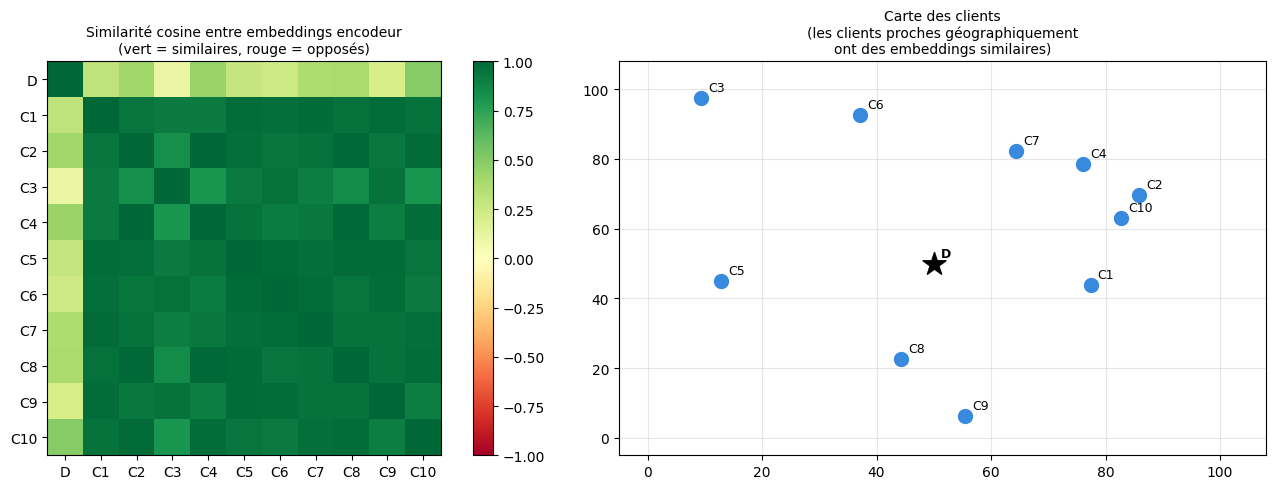

→ L'encodeur est calculé UNE SEULE FOIS par instance.
  On réutilise h à chaque décision du décodeur.


In [4]:
nf_batch = nf_torch.unsqueeze(0)   # (1, N+1, 7) — dimension batch

with torch.no_grad():
    h = model.encode(nf_batch)     # (1, N+1, 128)

h0 = h[0]   # (N+1, 128) — enlever la dimension batch

print(f"Sortie encodeur h — shape {list(h0.shape)}")
print()
print("Chaque nœud a maintenant un embedding de 128 dimensions")
print("qui intègre des informations sur TOUS ses voisins.")
print()

# Visualiser la similarité cosine entre embeddings
norms  = h0.norm(dim=1, keepdim=True)
h_norm = h0 / norms
sim    = (h_norm @ h_norm.T).numpy()

labels = ['D'] + [f'C{i}' for i in range(1, N + 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap similarité
ax = axes[0]
im = ax.imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('Similarité cosine entre embeddings encodeur\n(vert = similaires, rouge = opposés)', fontsize=10)
ax.set_xticks(range(N + 1)); ax.set_xticklabels(labels)
ax.set_yticks(range(N + 1)); ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax)

# Carte des clients avec leurs coordonnées
ax2 = axes[1]
coords = instance['coords']
ax2.scatter(coords[1:, 0], coords[1:, 1], c='#378ADD', s=100, zorder=3)
ax2.scatter(coords[0, 0], coords[0, 1], c='black', s=300, marker='*', zorder=5, label='Dépôt')
for i in range(1, N + 1):
    ax2.annotate(f'C{i}', xy=coords[i], xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.annotate('D', xy=coords[0], xytext=(5, 5), textcoords='offset points', fontsize=9, weight='bold')
ax2.set_title('Carte des clients\n(les clients proches géographiquement\nont des embeddings similaires)', fontsize=10)
ax2.set_xlim(-5, 108); ax2.set_ylim(-5, 108)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ L'encodeur est calculé UNE SEULE FOIS par instance.")
print("  On réutilise h à chaque décision du décodeur.")

---
## Étape 4 — La requête : ce que le véhicule cherche

À chaque décision, le véhicule construit une **requête** qui résume son état courant :

```
h_current = h[nœud_courant]       ← "où je suis" (128 dims)
h_mean    = moyenne de tous les h  ← "résumé global de l'instance" (128 dims)
g         = global_proj(état)      ← "capacité, heure, avancement..." (128 dims)

ctx   = [h_current | h_mean | g]  ← concaténer → 384 dims
query = context_proj(ctx)          ← W(128×384) + b → 128 dims

q     = W_q · query                ← W(128×128), sans biais → 128 dims
```

`q` est le vecteur **"voici ce que je cherche"** — il change à chaque décision.

In [5]:
# Préparer les tenseurs de la première décision
ex  = examples[0]
af  = torch.tensor(ex['action_features'], dtype=torch.float32).unsqueeze(0)   # (1, N+1, 5)
cn  = torch.tensor([ex['current_node']],  dtype=torch.long)                    # (1,)
dg  = torch.tensor(ex['dynamic_global'],  dtype=torch.float32).unsqueeze(0)   # (1, 6)
fm  = torch.tensor(ex['feasible_mask'],   dtype=torch.float32).unsqueeze(0)   # (1, N+1)

with torch.no_grad():
    # Construction manuelle de la requête
    batch_idx = torch.arange(1)
    h_current = h[batch_idx, cn]                                  # (1, 128)
    h_mean    = h.mean(dim=1)                                      # (1, 128)
    g         = model.global_proj(dg)                              # (1, 128)

    ctx   = torch.cat([h_current, h_mean, g], dim=-1)             # (1, 384)
    query = model.context_proj(ctx)                                # (1, 128)
    q     = model.W_q(query).unsqueeze(1)                         # (1, 1, 128)

print("Construction de la requête (décision 1 — depuis le dépôt) :")
print()
print(f"  Nœud courant          : {ex['current_node']} (dépôt)")
print(f"  État global (dg)      : {dg.squeeze().numpy().round(3)}")
print()
print(f"  h_current — shape {list(h_current.shape)} : norme={h_current.norm():.2f}")
print(f"  h_mean    — shape {list(h_mean.shape)} : norme={h_mean.norm():.2f}")
print(f"  g         — shape {list(g.shape)} : norme={g.norm():.2f}")
print()
print(f"  ctx   = [h_current | h_mean | g] — shape {list(ctx.shape)}")
print(f"  query = context_proj(ctx)        — shape {list(query.shape)}")
print(f"  q     = W_q(query)               — shape {list(q.shape)}")
print()
print("→ q est le vecteur 'ce que je cherche'. Il change à chaque décision.")

Construction de la requête (décision 1 — depuis le dépôt) :

  Nœud courant          : 0 (dépôt)
  État global (dg)      : [0.    0.    0.    0.    0.333 0.   ]

  h_current — shape [1, 128] : norme=29.08
  h_mean    — shape [1, 128] : norme=11.43
  g         — shape [1, 128] : norme=3.19

  ctx   = [h_current | h_mean | g] — shape [1, 384]
  query = context_proj(ctx)        — shape [1, 128]
  q     = W_q(query)               — shape [1, 1, 128]

→ q est le vecteur 'ce que je cherche'. Il change à chaque décision.


---
## Étape 5 — Les clés : ce que chaque ville propose

Chaque ville construit une **clé** qui décrit ce qu'elle peut offrir **dans le contexte courant** :

```
Pour chaque nœud i :
  clé_brute_i = key_proj([h_i | action_features_i])   ← W(128×133) + b → 128 dims
  k_i         = W_k · clé_brute_i                      ← W(128×128), sans biais → 128 dims
```

Pourquoi concaténer `h_i` (statique) et `action_features_i` (dynamique) ?

| Source | Contient | Exemple |
|--------|----------|---------|
| `h_i` | Position géographique, TW, demande — **en contexte global** | "je suis proche du cluster Nord" |
| `action_features_i` | Distance depuis position courante, slack TW restant... | "il te faudrait 12 min pour m'atteindre" |

Sans `action_features`, la clé du client 5 serait **identique** quel que soit l'état du véhicule.

In [6]:
with torch.no_grad():
    # Construction manuelle des clés
    cles_brutes = model.key_proj(torch.cat([h, af], dim=-1))   # (1, N+1, 128)
    k           = model.W_k(cles_brutes)                        # (1, N+1, 128)

print("Construction des clés :")
print()
print(f"  h   (embeddings encodeur) — shape {list(h.shape)}")
print(f"  af  (action features)     — shape {list(af.shape)}")
print(f"  cat([h, af])              — shape {list(torch.cat([h, af], dim=-1).shape)}")
print(f"  key_proj(cat)             — shape {list(cles_brutes.shape)}")
print(f"  k = W_k(clés_brutes)      — shape {list(k.shape)}")
print()

# Afficher les normes des clés
print("Norme de la clé de chaque nœud :")
for i in range(N + 1):
    label    = 'Dépôt ' if i == 0 else f'Client {i}'
    faisable = '(faisable)' if fm[0, i] > 0 else '(masqué) '
    print(f"  {label:8} {faisable}  norme={k[0, i].norm():.3f}")

print()
print("→ Chaque nœud a sa propre clé de 128 dimensions.")
print("  La clé mélange ce que le nœud 'est' (h) et ce qu'il 'offre' (action_features).")

Construction des clés :

  h   (embeddings encodeur) — shape [1, 11, 128]
  af  (action features)     — shape [1, 11, 5]
  cat([h, af])              — shape [1, 11, 133]
  key_proj(cat)             — shape [1, 11, 128]
  k = W_k(clés_brutes)      — shape [1, 11, 128]

Norme de la clé de chaque nœud :
  Dépôt    (masqué)   norme=13.078
  Client 1 (faisable)  norme=5.436
  Client 2 (faisable)  norme=7.236
  Client 3 (faisable)  norme=5.746
  Client 4 (faisable)  norme=7.898
  Client 5 (faisable)  norme=5.940
  Client 6 (faisable)  norme=5.127
  Client 7 (faisable)  norme=5.124
  Client 8 (faisable)  norme=7.131
  Client 9 (faisable)  norme=5.706
  Client 10 (faisable)  norme=6.754

→ Chaque nœud a sa propre clé de 128 dimensions.
  La clé mélange ce que le nœud 'est' (h) et ce qu'il 'offre' (action_features).


---
## Étape 6 — La comparaison : score = q · k

On compare la requête `q` avec la clé `k_i` de chaque nœud via un **produit scalaire** :

```
score_i = q · k_i = q[0]×k_i[0] + q[1]×k_i[1] + ... + q[127]×k_i[127]
```

**Intuition** :
- Si `q` et `k_i` pointent dans la **même direction** → produit scalaire **grand positif** → nœud pertinent
- Si `q` et `k_i` sont **perpendiculaires** → produit scalaire ≈ **0** → nœud neutre
- Si `q` et `k_i` sont dans des **directions opposées** → produit scalaire **grand négatif** → nœud non pertinent

En matriciel (tous les nœuds en une fois) :
```
scores = (q @ kᵀ).squeeze()
         (1, 1, 128) @ (1, 128, N+1) = (1, 1, N+1) → squeeze → (N+1,)
```

In [7]:
with torch.no_grad():
    # Produit scalaire q · k pour tous les nœuds en une fois
    scores_bruts = (q @ k.transpose(-1, -2)).squeeze()   # (N+1,)

print("Produit scalaire q · k_i (scores bruts) :")
print()
print(f"  q.shape         = {list(q.shape)}")
print(f"  k.shape         = {list(k.shape)}")
print(f"  k.T.shape       = {list(k.transpose(-1,-2).shape)}")
print(f"  (q @ k.T).shape = {list((q @ k.transpose(-1,-2)).shape)}")
print(f"  après squeeze   = {list(scores_bruts.shape)}")
print()

oracle   = ex['target_next_node']

print(f"{'Nœud':>8} | {'Score brut':>12} | {'Faisable':>9} |")
print("-" * 38)
for i in range(N + 1):
    label    = 'Dépôt' if i == 0 else f'C{i}'
    faisable = '✓' if fm[0, i] > 0 else '✗'
    note     = ' ← ORACLE' if i == oracle else ''
    print(f"{label:>8} | {scores_bruts[i].item():>12.3f} | {faisable:>9} |{note}")

print()
print(f"→ Le nœud oracle (C{oracle}) a le score le plus élevé parmi les faisables : {scores_bruts[oracle].item():.3f}")

Produit scalaire q · k_i (scores bruts) :

  q.shape         = [1, 1, 128]
  k.shape         = [1, 11, 128]
  k.T.shape       = [1, 128, 11]
  (q @ k.T).shape = [1, 1, 11]
  après squeeze   = [11]

    Nœud |   Score brut |  Faisable |
--------------------------------------
   Dépôt |     -258.328 |         ✗ |
      C1 |       30.889 |         ✓ |
      C2 |      -81.664 |         ✓ |
      C3 |       71.504 |         ✓ |
      C4 |     -101.141 |         ✓ |
      C5 |       -6.723 |         ✓ |
      C6 |       15.908 |         ✓ |
      C7 |       17.761 |         ✓ | ← ORACLE
      C8 |      -23.742 |         ✓ |
      C9 |       23.127 |         ✓ |
     C10 |      -55.718 |         ✓ |

→ Le nœud oracle (C7) a le score le plus élevé parmi les faisables : 17.761


---
## Étape 7 — Normalisation `/ √d` et clipping `10·tanh`

### Pourquoi diviser par `√128` ?

Le produit scalaire `q · k` additionne **128 termes**. En grande dimension, ces sommes peuvent devenir
très grandes — même si chaque terme est petit.

```
Si chaque dim ∈ [-1, 1]  →  q · k ∈ [-128, +128]  ← trop grand
Après / √128 ≈ / 11.3    →  score ∈ [-11,  +11]    ← mieux
```

Sans cette normalisation, le softmax **sature** (une proba = 1, toutes les autres = 0) → gradient nul → apprentissage bloqué.

### Pourquoi `10·tanh(s/10)` ?

C'est la **convention Kool et al. 2019**. Elle borne les scores dans `[-10, +10]`.
Même après `/√128`, les scores peuvent parfois atteindre ±20 ou ±30 lors de l'entraînement.
Le `tanh` garantit que la distribution reste douce — les gradients circulent bien.

Effet de la normalisation et du clipping :

    Nœud |     Brut |   / √128 |  10·tanh
--------------------------------------------
   Dépôt | -258.328 |  -22.833 |   -9.794
      C1 |   30.889 |    2.730 |    2.664
      C2 |  -81.664 |   -7.218 |   -6.180
      C3 |   71.504 |    6.320 |    5.594
      C4 | -101.141 |   -8.940 |   -7.133
      C5 |   -6.723 |   -0.594 |   -0.594
      C6 |   15.908 |    1.406 |    1.397
      C7 |   17.761 |    1.570 |    1.557
      C8 |  -23.742 |   -2.099 |   -2.068
      C9 |   23.127 |    2.044 |    2.016
     C10 |  -55.718 |   -4.925 |   -4.562

Avant normalisation : min=-258.33  max=71.50
Après / √128        : min=-22.83  max=6.32
Après 10·tanh       : min=-9.79  max=5.59


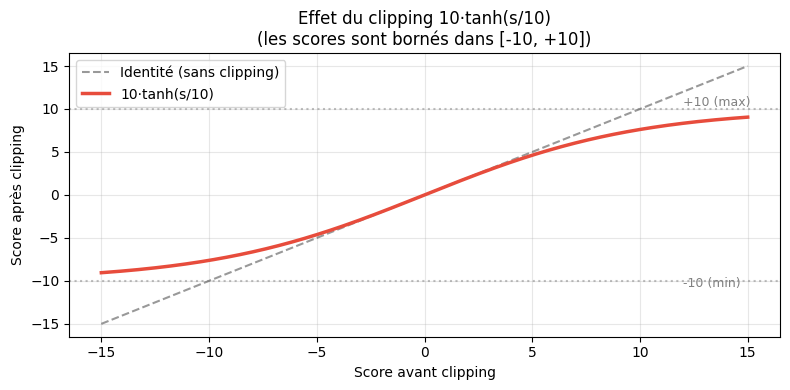

In [8]:
with torch.no_grad():
    scores_norm  = scores_bruts / (128 ** 0.5)               # / √128
    scores_clip  = 10.0 * torch.tanh(scores_norm / 10.0)     # 10·tanh

print("Effet de la normalisation et du clipping :")
print()
print(f"{'Nœud':>8} | {'Brut':>8} | {'/ √128':>8} | {'10·tanh':>8}")
print("-" * 44)
for i in range(N + 1):
    label = 'Dépôt' if i == 0 else f'C{i}'
    print(f"{label:>8} | {scores_bruts[i].item():>8.3f} | {scores_norm[i].item():>8.3f} | {scores_clip[i].item():>8.3f}")

print()
print(f"Avant normalisation : min={scores_bruts.min():.2f}  max={scores_bruts.max():.2f}")
print(f"Après / √128        : min={scores_norm.min():.2f}  max={scores_norm.max():.2f}")
print(f"Après 10·tanh       : min={scores_clip.min():.2f}  max={scores_clip.max():.2f}")

# Visualiser l'effet du tanh
fig, ax = plt.subplots(figsize=(8, 4))
s_range = torch.linspace(-15, 15, 300)
ax.plot(s_range.numpy(), s_range.numpy(), 'k--', alpha=0.4, label='Identité (sans clipping)')
ax.plot(s_range.numpy(), (10 * torch.tanh(s_range / 10)).numpy(), '#E74C3C', lw=2.5, label='10·tanh(s/10)')
ax.axhline(10,  color='gray', ls=':', alpha=0.5)
ax.axhline(-10, color='gray', ls=':', alpha=0.5)
ax.text(12, 10.3, '+10 (max)', fontsize=9, color='gray')
ax.text(12, -10.7, '-10 (min)', fontsize=9, color='gray')
ax.set_xlabel('Score avant clipping')
ax.set_ylabel('Score après clipping')
ax.set_title('Effet du clipping 10·tanh(s/10)\n(les scores sont bornés dans [-10, +10])')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Étape 8 — Le masque : bloquer les nœuds interdits

Certains nœuds ne peuvent pas être visités à ce moment :
- Déjà servis
- Fenêtre temporelle fermée (on arriverait trop tard)
- Capacité insuffisante

On leur assigne un score de `-1 000 000 000` avant le softmax :

```python
logits = scores.masked_fill(feasible_mask <= 0, -1e9)
```

Après softmax :
```
exp(-1e9) ≈ 0.0   →   proba = 0   →   jamais sélectionné
```

C'est le **décodeur contraint** — le modèle ne peut **pas** violer les contraintes VRPTW,
même si ses poids le suggèrent.

In [9]:
with torch.no_grad():
    logits = scores_clip.masked_fill(fm.squeeze() <= 0, -1e9)

print("Application du masque :")
print(f"  feasible_mask : {fm.squeeze().int().numpy()}")
print()
print(f"{'Nœud':>8} | {'Score clipé':>12} | {'Masque':>7} | {'Logit final':>14}")
print("-" * 50)
for i in range(N + 1):
    label    = 'Dépôt' if i == 0 else f'C{i}'
    faisable = fm[0, i].item()
    note     = ' ← MASQUÉ (-∞)' if faisable == 0 else ''
    print(f"{label:>8} | {scores_clip[i].item():>12.3f} | {'✓' if faisable else '✗':>7} | {logits[i].item():>14.1f}{note}")

Application du masque :
  feasible_mask : [0 1 1 1 1 1 1 1 1 1 1]

    Nœud |  Score clipé |  Masque |    Logit final
--------------------------------------------------
   Dépôt |       -9.794 |       ✗ |  -1000000000.0 ← MASQUÉ (-∞)
      C1 |        2.664 |       ✓ |            2.7
      C2 |       -6.180 |       ✓ |           -6.2
      C3 |        5.594 |       ✓ |            5.6
      C4 |       -7.133 |       ✓ |           -7.1
      C5 |       -0.594 |       ✓ |           -0.6
      C6 |        1.397 |       ✓ |            1.4
      C7 |        1.557 |       ✓ |            1.6
      C8 |       -2.068 |       ✓ |           -2.1
      C9 |        2.016 |       ✓ |            2.0
     C10 |       -4.562 |       ✓ |           -4.6


---
## Étape 9 — Softmax → probabilités → décision

Le softmax transforme les logits en **probabilités** :

```
proba_i = exp(logit_i) / Σ exp(logit_j)
```

- Les logits à `-1e9` donnent `exp(-1e9) ≈ 0` → proba = 0
- Les logits les plus élevés donnent les probas les plus hautes
- Toutes les probas somment à **1**

À l'**inférence** : on prend le nœud avec la proba maximale (`argmax`).

À l'**entraînement** : on compare la distribution à la décision de l'oracle via `CrossEntropyLoss`,
ce qui génère un gradient pour ajuster tous les `W` et `b` du modèle.

In [10]:
with torch.no_grad():
    probs = torch.softmax(logits, dim=0).numpy()

choix_modele = int(np.argmax(probs))
oracle_node  = ex['target_next_node']
correct      = choix_modele == oracle_node

print(f"Résultat de la décision 1 (depuis nœud {ex['current_node']}) :")
print()
print(f"{'Nœud':>8} | {'Logit':>8} | {'Proba (%)':>10} | {'':>5}")
print("-" * 42)
for i in range(N + 1):
    if fm[0, i] == 0:
        continue  # ne pas afficher les masqués
    label = 'Dépôt' if i == 0 else f'C{i}'
    annot = ''
    if i == oracle_node:   annot += ' ◄ ORACLE'
    if i == choix_modele and i != oracle_node: annot += ' ◄ MODÈLE'
    if i == choix_modele and i == oracle_node: annot += ' ◄ ORACLE & MODÈLE ✓'
    bar = '█' * int(probs[i] * 40)
    print(f"{label:>8} | {logits[i].item():>8.3f} | {probs[i]*100:>9.1f}% | {bar}{annot}")

print()
print(f"Choix du modèle : C{choix_modele}  —  Oracle : C{oracle_node}  —  {'✓ CORRECT' if correct else '✗ ERREUR'}")
print(f"Somme des probas (faisables) : {probs[fm[0].numpy() > 0].sum():.6f}  ← doit être 1.0")

Résultat de la décision 1 (depuis nœud 0) :

    Nœud |    Logit |  Proba (%) |      
------------------------------------------
      C1 |    2.664 |       4.8% | █
      C2 |   -6.180 |       0.0% | 
      C3 |    5.594 |      89.6% | ███████████████████████████████████ ◄ MODÈLE
      C4 |   -7.133 |       0.0% | 
      C5 |   -0.594 |       0.2% | 
      C6 |    1.397 |       1.3% | 
      C7 |    1.557 |       1.6% |  ◄ ORACLE
      C8 |   -2.068 |       0.0% | 
      C9 |    2.016 |       2.5% | █
     C10 |   -4.562 |       0.0% | 

Choix du modèle : C3  —  Oracle : C7  —  ✗ ERREUR
Somme des probas (faisables) : 1.000000  ← doit être 1.0


### Visualisation spatiale — que choisit le modèle ?

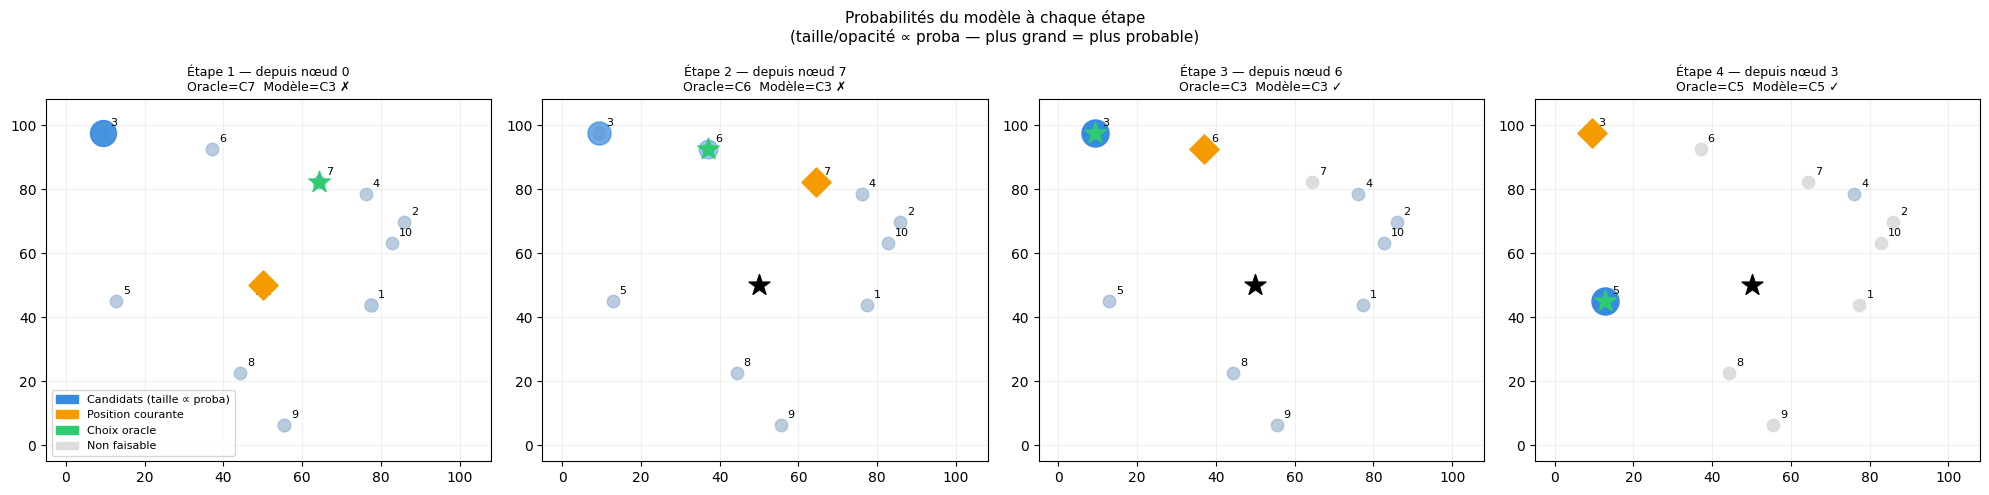

In [11]:
coords = instance['coords']

fig, axes = plt.subplots(1, min(4, len(examples)), figsize=(5 * min(4, len(examples)), 5))
if len(examples) == 1:
    axes = [axes]

for step, (ex_s, ax) in enumerate(zip(examples[:4], axes)):
    nf_s = torch.tensor(ex_s['node_features'],   dtype=torch.float32)
    af_s = torch.tensor(ex_s['action_features'], dtype=torch.float32)
    cn_s = torch.tensor(ex_s['current_node'],    dtype=torch.long)
    dg_s = torch.tensor(ex_s['dynamic_global'],  dtype=torch.float32)
    fm_s = torch.tensor(ex_s['feasible_mask'],   dtype=torch.float32)

    with torch.no_grad():
        logits_s = model(nf_s, af_s, cn_s, dg_s, fm_s).numpy()

    feasible_idx = np.where(fm_s.numpy() > 0)[0]
    logits_f     = logits_s[feasible_idx]
    probs_f      = np.exp(logits_f - logits_f.max())
    probs_f     /= probs_f.sum()

    # Fond gris pour tous les clients
    ax.scatter(coords[1:, 0], coords[1:, 1], c='#DDDDDD', s=80, zorder=2)
    ax.scatter(coords[0, 0],  coords[0, 1],  c='black',   s=250, marker='*', zorder=5)

    # Colorier selon la proba
    for fi, idx in enumerate(feasible_idx):
        if idx == 0:
            continue
        alpha = 0.2 + 0.8 * probs_f[fi]
        size  = 80 + 300 * probs_f[fi]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c='#378ADD', s=size, alpha=alpha, zorder=3)

    # Position courante
    ax.scatter(coords[ex_s['current_node'], 0], coords[ex_s['current_node'], 1],
               c='#F59B00', s=220, marker='D', zorder=6)

    # Choix oracle
    tgt = ex_s['target_next_node']
    if tgt != 0:
        ax.scatter(coords[tgt, 0], coords[tgt, 1],
                   c='#2ECC71', s=260, marker='*', zorder=7)

    for i in range(1, N + 1):
        ax.annotate(str(i), xy=coords[i], xytext=(5, 5),
                    textcoords='offset points', fontsize=8)

    modele_choix = feasible_idx[np.argmax(probs_f)]
    correct_s    = '✓' if modele_choix == tgt else '✗'
    ax.set_title(f'Étape {step + 1} — depuis nœud {ex_s["current_node"]}\n'
                 f'Oracle=C{tgt}  Modèle=C{modele_choix} {correct_s}', fontsize=9)
    ax.set_xlim(-5, 108); ax.set_ylim(-5, 108)
    ax.grid(True, alpha=0.2)

# Légende
legend = [
    mpatches.Patch(color='#378ADD', label='Candidats (taille ∝ proba)'),
    mpatches.Patch(color='#F59B00', label='Position courante'),
    mpatches.Patch(color='#2ECC71', label='Choix oracle'),
    mpatches.Patch(color='#DDDDDD', label='Non faisable'),
]
axes[0].legend(handles=legend, fontsize=8, loc='lower left')

fig.suptitle('Probabilités du modèle à chaque étape\n'
             '(taille/opacité ∝ proba — plus grand = plus probable)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Récapitulatif — Pipeline complet Key → Logit

```
Étape 1 : nn.Linear (W · x + b)    ← brique fondamentale, apprise par gradient descent

Étape 2 : features brutes (7)      → input_proj → espace machine (128)

Étape 3 : encodeur Transformer     → h (N+1, 128)  ← chaque nœud voit tous les autres
           (calculé 1× par instance)

Étape 4 : REQUÊTE                  q = W_q( context_proj([h_cur | h_mean | g]) )
           "ce que le véhicule cherche"   — change à chaque décision

Étape 5 : CLÉS                     k = W_k( key_proj([h_i | action_i]) )
           "ce que chaque ville offre"    — change à chaque décision

Étape 6 : SCORE                    score_i = q · k_i
           produit scalaire = mesure de similarité

Étape 7 : NORMALISATION            score / √128   (éviter l'explosion)
           CLIPPING                10·tanh(s/10)  (borner dans [-10, +10])

Étape 8 : MASQUE                   score = -1e9 si nœud infaisable

Étape 9 : SOFTMAX                  proba = softmax(logits)
           → argmax → prochain nœud
```

**695 936 paramètres** (`W` et `b`) appris simultanément par gradient descent
pour que les routes produites soient les plus courtes possible.

→ **Section 5** : `05_entrainement.ipynb` — comment on optimise ces paramètres.

In [12]:
# Vue d'ensemble des dimensions à chaque étape du pipeline
print("Pipeline complet — dimensions à chaque étape")
print("=" * 60)
print()

etapes = [
    ("Entrée brute",           "(N+1, 7)",     "features humaines"),
    ("input_proj",             "(N+1, 128)",   "espace machine"),
    ("encoder (h)",            "(N+1, 128)",   "avec contexte global"),
    ("[h_cur|h_moy|g]",        "(384,)",       "état véhicule concat"),
    ("context_proj → query",   "(128,)",       "requête condensée"),
    ("W_q → q",                "(1, 128)",     "requête finale"),
    ("[h_i|af_i] par nœud",    "(N+1, 133)",   "clé concat"),
    ("key_proj → clés brutes", "(N+1, 128)",   "clés enrichies"),
    ("W_k → k",                "(N+1, 128)",   "clés finales"),
    ("q @ kᵀ / √128",          "(N+1,)",       "scores normalisés"),
    ("10·tanh(s/10)",          "(N+1,)",       "scores bornés [-10,10]"),
    ("masked_fill",            "(N+1,)",       "logits (-∞ sur masqués)"),
    ("softmax",                "(N+1,)",       "probabilités (somme=1)"),
    ("argmax",                 "scalaire",     "prochain nœud choisi"),
]

for nom, shape, desc in etapes:
    print(f"  {nom:<26} {shape:<14} ← {desc}")

print()
print("=" * 60)
n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres appris : {n_params:,} (tous les W et b du modèle)")

Pipeline complet — dimensions à chaque étape

  Entrée brute               (N+1, 7)       ← features humaines
  input_proj                 (N+1, 128)     ← espace machine
  encoder (h)                (N+1, 128)     ← avec contexte global
  [h_cur|h_moy|g]            (384,)         ← état véhicule concat
  context_proj → query       (128,)         ← requête condensée
  W_q → q                    (1, 128)       ← requête finale
  [h_i|af_i] par nœud        (N+1, 133)     ← clé concat
  key_proj → clés brutes     (N+1, 128)     ← clés enrichies
  W_k → k                    (N+1, 128)     ← clés finales
  q @ kᵀ / √128              (N+1,)         ← scores normalisés
  10·tanh(s/10)              (N+1,)         ← scores bornés [-10,10]
  masked_fill                (N+1,)         ← logits (-∞ sur masqués)
  softmax                    (N+1,)         ← probabilités (somme=1)
  argmax                     scalaire       ← prochain nœud choisi

Paramètres appris : 695,936 (tous les W et b du modèl